In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


In [2]:
import os
print(os.listdir(path))

['Housing.csv']


In [3]:
#Task 1

In [4]:
import pandas as pd
df=pd.read_csv(os.path.join(path,"Housing.csv"))

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
df.shape

(545, 13)

In [7]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
#Task2

In [9]:
df = df.dropna()

In [10]:
df.shape

(545, 13)

In [11]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [12]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [13]:
df = pd.get_dummies(df,
                    columns=categorical_columns,
                    drop_first=True,
                    dtype=int)

In [14]:
df

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [15]:
#Task3

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#model 1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [18]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [19]:
y=lr.predict(X_test)

In [22]:
print("MSE:", mean_squared_error(y_test, y))
print("R2:", r2_score(y_test, y))
print("MAE:", mean_absolute_error(y_test, y))
print("RMSE:", root_mean_squared_error(y_test, y))

MSE: 1754318687330.6638
R2: 0.6529242642153184
MAE: 970043.4039201636
RMSE: 1324506.9600914386


In [23]:
#model 2
from sklearn.ensemble import RandomForestRegressor

In [24]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [26]:
a=rf.predict(X_test)

In [27]:
print("MSE:", mean_squared_error(y_test, a))
print("R2:", r2_score(y_test, a))
print("MAE:", mean_absolute_error(y_test, a))

MSE: 1989137513882.543
R2: 0.6064675299912774
MAE: 1018033.7914373089


In [28]:
#Task 4

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

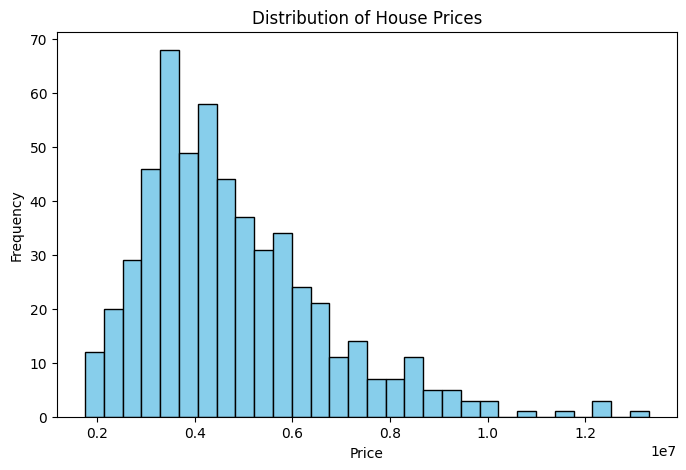

In [30]:
#chart1-Histogram
plt.figure(figsize=(8,5))

plt.hist(df["price"],
         bins=30,
         color="skyblue",
         edgecolor="black")

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

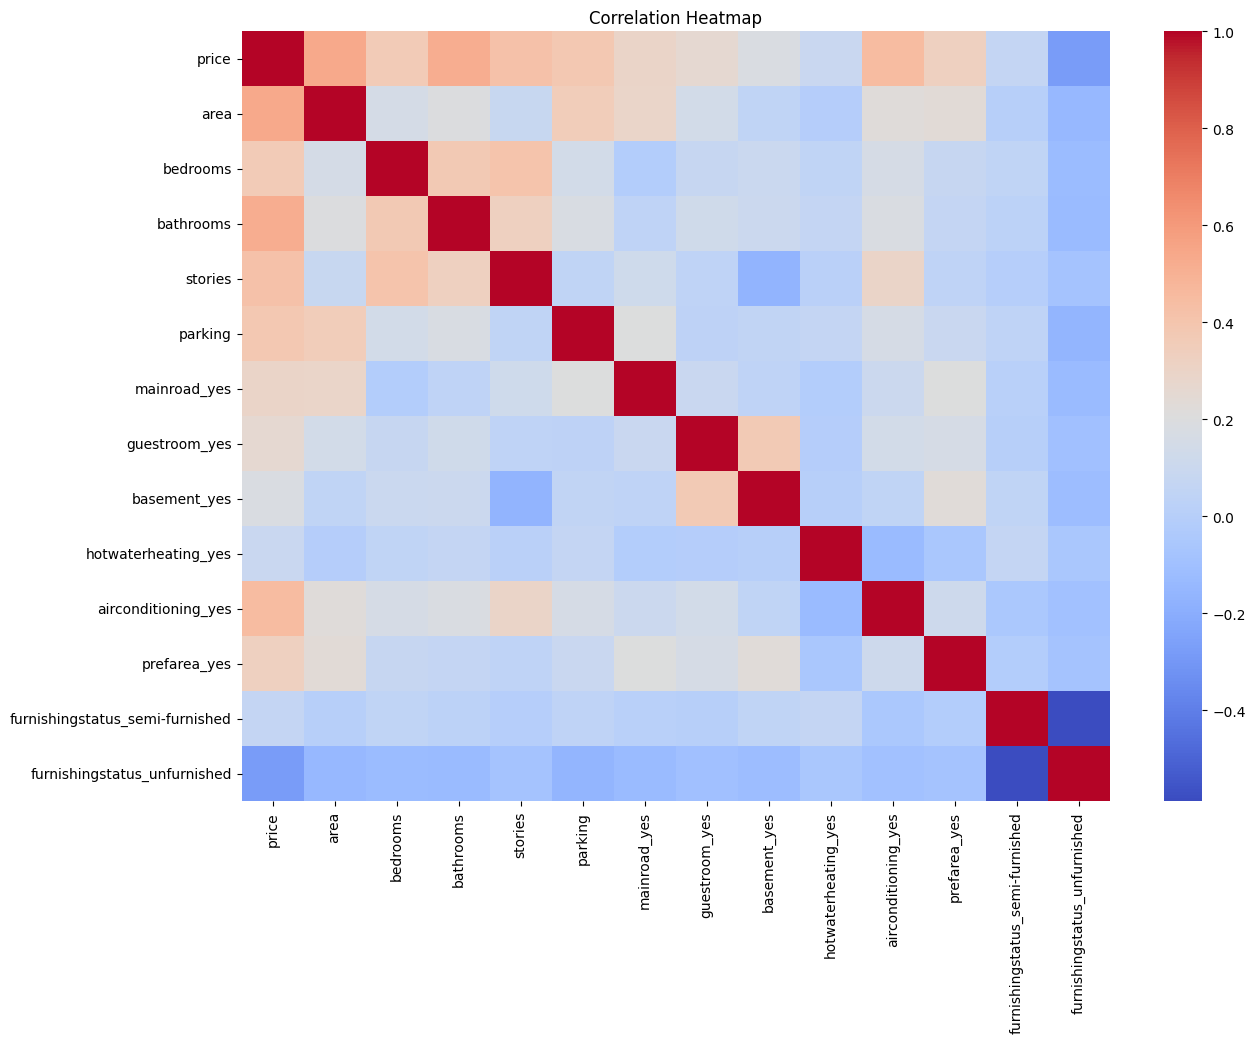

In [31]:
#chart2-Correlation heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

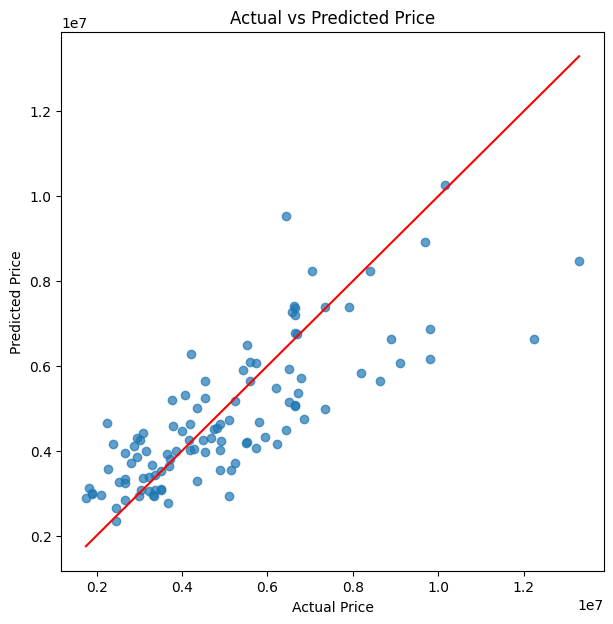

In [34]:
#chart3-Scatter plot
plt.figure(figsize=(7,7))

plt.scatter(y_test,
            a,
            alpha=0.7)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [ ]:
""" The Linear Regression model performed better than the Random Forest Regressor  ,
indicating that house prices have linear relationships with several property features.
The most influential features were typically the area of the house, number of bathrooms,
air conditioning, parking spaces, and whether the house is located in a preferred area.
The linear regression model achieved a high R² score-0.6529242642153184, meaning it explained a large proportion of the variation in house prices.
One interesting observation was that amenities such as air conditioning and furnishing status significantly affected price,
sometimes more than the number of bedrooms.
Based on these findings, real estate businesses should prioritize highlighting high-impact
features in listings and use machine learning models to generate more accurate property valuations."""